In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

In [2]:
import numpy as np
from scipy.spatial import KDTree

def find_overlap_points(df_query, df_ref, dist_thresh=0.06):
    xr_ref = np.log10(df_ref["size"])
    yr_ref = df_ref["average plasmid fraction-pident_90"]
    
    all_x = np.concatenate([xr_ref, np.log10(df_query["size"])])
    all_y = np.concatenate([yr_ref, df_query["average plasmid fraction-pident_90"]])
    
    def minmax(v, vmin, vmax):
        return (v - vmin) / (vmax - vmin)
    
    x_min, x_max = all_x.min(), all_x.max()
    y_min, y_max = all_y.min(), all_y.max()
    
    xr_ref_norm = minmax(xr_ref, x_min, x_max)
    yr_ref_norm = minmax(yr_ref, y_min, y_max)
    coords_ref = np.column_stack([xr_ref_norm, yr_ref_norm])
    tree = KDTree(coords_ref)

    xq = np.log10(df_query["size"])
    yq = df_query["average plasmid fraction-pident_90"]
    xq_norm = minmax(xq, x_min, x_max)
    yq_norm = minmax(yq, y_min, y_max)
    coords_query = np.column_stack([xq_norm, yq_norm])

    dists, idx_nearest = tree.query(coords_query, k=1)
    mask_overlap = dists < dist_thresh
    
    overlap_query = df_query[mask_overlap].copy()
    overlap_query["nn_distance_norm"] = dists[mask_overlap]
    overlap_query["ref_match_index"] = idx_nearest[mask_overlap]

    matched_ref_rows = df_ref.iloc[idx_nearest[mask_overlap]].reset_index(drop=True)
    matched_ref_unique = matched_ref_rows.drop_duplicates().reset_index(drop=True)
    
    overlap_combined = overlap_query.reset_index(drop=True)
    overlap_combined = overlap_combined.join(
        matched_ref_rows.add_prefix("ref_"), how="left"
    )
    return overlap_combined, matched_ref_unique
    
def process_replicon_data(fraction_data, label = 'pident_90'):
    typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
    min_size = min(typ_chr['size'])
    tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
    if tra_rep.empty:
        return min_size * 0.5
    else:
        tra_max = max(tra_rep['size'])
        return (min_size + tra_max)/2

def scatter_figure(ax, df, title_text, ref_df, label = 'pident_90', color='gray', alpha=1):
    ax.scatter(
        df['size'],
        df[f'average plasmid fraction-{label}'],
        color=color,
        edgecolors='none',
        s=5, alpha=alpha, zorder=3
    )

    ax.set_xlabel('Size / bp', labelpad=0)
    ax.set_ylabel('Plasmidness', labelpad=0)
    ax.set_xscale('log')
    ax.set_title(title_text)
    ax.set_xlim(100, 5e7)
    ax.tick_params(axis='both')
    
    size_split = process_replicon_data(ref_df, label)
    x_min, x_max = 100, 5e7
    y_min, y_max = -0.1, 1.1
    threshold = 0.3
    ax.axhline(y=threshold, color='gray', linestyle='--', linewidth=0.8)
    
    rect1 = Rectangle((x_min, threshold), x_max-x_min, y_max-threshold, facecolor='#cce7ff', alpha=0.8, zorder=1)
    ax.add_patch(rect1)
    rect2 = Rectangle((x_min, y_min), size_split-x_min, threshold-y_min, facecolor='#e6f7e6', alpha=0.8, zorder=1)
    ax.add_patch(rect2)
    rect3 = Rectangle((size_split, y_min), x_max-size_split, threshold-y_min, facecolor='#f9e4c8', alpha=0.8, zorder=1)
    ax.add_patch(rect3)

In [3]:
from Bio import SeqIO
from Bio.SeqFeature import CompoundLocation

def load_gbff_with_bio(gbff_path, target_contig_id=None):
    contig_list = []
    for record in SeqIO.parse(gbff_path, "genbank"):
        rec_id = record.id
        if target_contig_id is not None and rec_id != target_contig_id:
            continue
        rec_len = len(record.seq)
        gene_groups = []
        for feat in record.features:
            feat_type = feat.type
            if feat_type not in ("CDS", "tRNA", "rRNA"):
                continue
            loc = feat.location
            rev = loc.strand == -1
            subs = loc.parts if isinstance(loc, CompoundLocation) else [loc]
            seg_coords = [(p.start, p.end) for p in subs]
            gene_groups.append((feat_type, rev, seg_coords))
        contig_list.append((rec_id, rec_len, gene_groups))
    return contig_list

def draw_gbff_block_features(ax, contig, x_pos, y_pos, arrow_len = 300):
    ctg_id, total_bp, gene_groups = contig
    feat_color = {"CDS":"#e74c3c","tRNA":"#2ecc71","rRNA":"#f39c12"}
    feat_edge = "#222222"
    full_tri_h = 0.5
    rect_h = full_tri_h * 0.65
    h_tri_half = full_tri_h / 2
    h_rect_half = rect_h / 2
    for f_type, rev, seg_list in gene_groups:
        fill_c = feat_color[f_type]
        if len(seg_list) > 1:
            all_p = []
            for s,e in seg_list: all_p.extend([s,e])
            min_p,max_p = min(all_p),max(all_p)
            seg_sorted = sorted(seg_list, key=lambda x:x[0])
            if max_p - min_p == total_bp:
                gaps = []
                for i in range(len(seg_sorted)-1):
                    s_curr,e_curr = seg_sorted[i]
                    s_next,_ = seg_sorted[i+1]
                    gaps.append(s_next - e_curr)
                wrap_gap_idx = np.argmax(gaps)
                seg_bounds = seg_sorted[wrap_gap_idx+1:] + seg_sorted[:wrap_gap_idx+1]
            else:
                seg_bounds = seg_sorted
        else:
            seg_bounds = seg_list
        if not rev:
            tip_seg_idx = len(seg_bounds) - 1
        else:
            tip_seg_idx = 0
        for seg_idx,(s_seg,e_seg) in enumerate(seg_bounds):
            seg_len = e_seg - s_seg
            s_draw = x_pos + s_seg
            e_draw = x_pos + e_seg
            if seg_idx != tip_seg_idx:
                rect_poly = np.array([[s_draw, y_pos + h_rect_half],[s_draw, y_pos - h_rect_half],[e_draw, y_pos - h_rect_half],[e_draw, y_pos + h_rect_half],[s_draw, y_pos + h_rect_half]])
                p = plt.Polygon(rect_poly, facecolor=fill_c, alpha=0.75, ec=feat_edge, lw=0.5, zorder=3)
                ax.add_patch(p)
            else:
                rect_len = seg_len - arrow_len
                poly_points = []
                if rect_len <= 0:
                    if rev:
                        poly_points = np.array([[s_draw, y_pos],[e_draw, y_pos - h_tri_half],[e_draw, y_pos + h_tri_half],[s_draw, y_pos]])
                    else:
                        poly_points = np.array([[e_draw, y_pos],[s_draw, y_pos - h_tri_half],[s_draw, y_pos + h_tri_half],[e_draw, y_pos]])
                else:
                    if rev:
                        tri_tip = s_draw
                        joint_x = s_draw + arrow_len
                        poly_points = np.array([[tri_tip, y_pos],[joint_x, y_pos + h_tri_half],[joint_x, y_pos + h_rect_half],[e_draw, y_pos + h_rect_half],[e_draw, y_pos - h_rect_half],[joint_x, y_pos - h_rect_half],[joint_x, y_pos - h_tri_half],[tri_tip, y_pos]])
                    else:
                        tri_tip = e_draw
                        joint_x = e_draw - arrow_len
                        poly_points = np.array([[tri_tip, y_pos],[joint_x, y_pos + h_tri_half],[joint_x, y_pos + h_rect_half],[s_draw, y_pos + h_rect_half],[s_draw, y_pos - h_rect_half],[joint_x, y_pos - h_rect_half],[joint_x, y_pos - h_tri_half],[tri_tip, y_pos]])
                gene_poly = plt.Polygon(poly_points, facecolor=fill_c, alpha=0.75, ec=feat_edge, lw=0.5, zorder=3)
                ax.add_patch(gene_poly)

In [4]:
# sequence_aligment_picture
import os
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio.SeqFeature import CompoundLocation
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import matplotlib.patches as mpatches


def identity_to_color(base_hex, identity, ID_MIN=70, ID_MAX=100, FIXED_ALPHA=0.8):
    identity = np.clip(identity, ID_MIN, ID_MAX)
    ratio = (identity - ID_MIN) / (ID_MAX - ID_MIN)
    base_rgb = np.array(mcolors.hex2color(base_hex))
    start_rgb = (np.array([1.0, 1.0, 1.0]) * 2/3) + (base_rgb * 1/3)
    final_rgb = start_rgb * (1 - ratio) + base_rgb * ratio
    return (*final_rgb, FIXED_ALPHA)


def plot_synteny_blocks(ax, df, s1_line, s2_line, BASE_NORMAL="#bbbbbb", BASE_CROSS="#73a9c2", ID_MIN=70, ID_MAX=100):
    s1_x_data = s1_line[0].get_xdata()
    s1_y_data = s1_line[0].get_ydata()

    s1_x_start = s1_x_data[0]
    s1_x_end   = s1_x_data[1]
    s1_y       = s1_y_data[0]

    s2_x_data = s2_line[0].get_xdata()
    s2_y_data = s2_line[0].get_ydata()

    s2_x_start = s2_x_data[0]
    s2_x_end   = s2_x_data[1]
    s2_y       = s2_y_data[0]
    
    def draw_single_band(ax, s1_start, s1_end, s2_start, s2_end, identity):
        mid_y = (s1_y + s2_y) / 2
        dir_s1 = s1_end > s1_start
        dir_s2 = s2_end > s2_start
        is_cross = dir_s1 != dir_s2
        
        base = BASE_CROSS if is_cross else BASE_NORMAL
        color = identity_to_color(base, identity, ID_MIN=ID_MIN, ID_MAX=ID_MAX)

        verts = [
            (s1_start + s1_x_start, s1_y),
            (s1_start + s1_x_start, mid_y),
            (s2_start + s2_x_start, mid_y),
            (s2_start + s2_x_start, s2_y),

            (s2_end   + s2_x_start, s2_y),
            (s2_end   + s2_x_start, mid_y),
            (s1_end   + s1_x_start, mid_y),
            (s1_end   + s1_x_start, s1_y),

            (s1_start + s1_x_start, s1_y)
        ]

        codes = [
            mpath.Path.MOVETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO,
            mpath.Path.LINETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO, mpath.Path.CLOSEPOLY
        ]
        patch = mpatches.PathPatch(mpath.Path(verts, codes), facecolor=color, edgecolor="none")
        ax.add_patch(patch)

    for _, row in df.iterrows():
        draw_single_band(ax, 
            row["qstart"], row["qend"],
            row["sstart"], row["send"],
            row["pident"]
        )


def _export_single_contig(contig_id: str, contig_file_info: dict, out_fasta: str):
    info = contig_file_info[contig_id]
    file_path = info["path"]
    fmt = info["fmt"]

    out_handle = open(out_fasta, "w")
    with open(file_path, "r") as in_handle:
        for seq_record in SeqIO.parse(in_handle, fmt):
            if seq_record.id == contig_id.split('-')[-1]:
                seq_record.id = contig_id
                SeqIO.write(seq_record, out_handle, "fasta")
                break
    out_handle.close()


def sequence_alignment(query_contig: str, sub_contig: str, contig_file_info: dict, ident_thr=90, len_thr=0, temp_dir="/active-data/temp") -> pd.DataFrame:
    os.makedirs(temp_dir, exist_ok=True)
    q_fasta = os.path.join(temp_dir, "temp_query.fasta")
    s_fasta = os.path.join(temp_dir, "temp_subject.fasta")
    blast_out = os.path.join(temp_dir, "blastn_results.txt")

    _export_single_contig(query_contig, contig_file_info, q_fasta)
    _export_single_contig(sub_contig, contig_file_info, s_fasta)

    blast_cmd = (
        f'blastn -query {q_fasta} -subject {s_fasta} -out {blast_out} '
        f'-evalue 1e-50 -max_target_seqs 100000 -outfmt 6'
    )
    os.system(blast_cmd)

    header = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen',
              'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
    align_result = pd.read_csv(blast_out, sep='\t', engine='python', header=None, names=header)
    align_result = align_result[(align_result["pident"] >= ident_thr) &
                                (align_result["length"] >= len_thr)].reset_index(drop=True)

    for tmp_file in [q_fasta, s_fasta, blast_out]:
        if os.path.exists(tmp_file):
            os.remove(tmp_file)
    return align_result


def draw_colorbar_legend(ax, rel_x=0.80, rel_y=0.85, width=0.02, height=0.25, gap=0.01, ID_MIN=70, ID_MAX=100):
    n_steps = 50
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    data_w = x1 - x0
    data_h = y1 - y0

    x_start = x0 + rel_x * data_w
    y_top = y0 + rel_y * data_h
    y_bottom = y_top - height * data_h

    x1_left = x_start
    x1_right = x_start + width * data_w
    x2_left = x1_right + gap * data_w
    x2_right = x2_left + width * data_w

    ys = np.linspace(y_top, y_bottom, n_steps)
    dy = ys[1] - ys[0]

    BASE_NORMAL = "#bbbbbb"
    BASE_CROSS  = "#73a9c2"

    for i in range(n_steps):
        id_val = ID_MAX - (ID_MAX - ID_MIN) * (i / (n_steps - 1))
        c1 = identity_to_color(BASE_NORMAL, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        c2 = identity_to_color(BASE_CROSS, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        ax.fill_between([x1_left, x1_right], ys[i], ys[i]+dy, color=c1, ec="none")
        ax.fill_between([x2_left, x2_right], ys[i], ys[i]+dy, color=c2, ec="none")

    ax.plot([x1_left, x1_right, x1_right, x1_left, x1_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)
    ax.plot([x2_left, x2_right, x2_right, x2_left, x2_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)

    mid_x = (x1_left + x2_right) / 2
    ax.text(x1_left, (y_top + y_bottom)/2, "Identity", ha="right", va="bottom")
    ax.text(mid_x, y_top + 0.02, f"{ID_MAX}%", ha="center", va="bottom")
    ax.text(mid_x, y_bottom - 0.02, f"{ID_MIN}%", ha="center", va="top")


def add_length_bar(ax, bar_length=2000):
    x_max = ax.get_xlim()[1]
    x_start = x_max * 0.85
    y_pos = 0.5
    ax.plot([x_start, x_start + bar_length], [y_pos, y_pos], color='black', lw=1)
    ax.plot([x_start, x_start], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.plot([x_start+bar_length, x_start+bar_length], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.text(x_start + bar_length/2, y_pos - 0.15, f'{bar_length} bp', ha='center', va='top')


def get_align_results(contig_pair_list: list, contig_file_info: dict, ident_thr=90, len_thr=0):
    all_res = []
    for q_ctg, s_ctg in contig_pair_list:
        df = sequence_alignment(q_ctg, s_ctg, contig_file_info, ident_thr=ident_thr, len_thr=len_thr)
        all_res.append(df)
    return pd.concat(all_res, ignore_index=True)


def get_contig_length(contig_file_info: dict) -> dict:
    len_dict = {}
    for contig_id in contig_file_info:
        info = contig_file_info[contig_id]
        path = info["path"]
        fmt = info["fmt"]
        with open(path, "r") as handle:
            for rec in SeqIO.parse(handle, fmt):
                if rec.id == contig_id.split('-')[-1]:
                    len_dict[contig_id] = len(rec)
    return len_dict

def load_gbff_with_bio(gbff_path, target_contig_id=None):
    contig_info_list = []
    for record in SeqIO.parse(gbff_path, "genbank"):
        rec_id = record.id
        if target_contig_id is not None and rec_id not in target_contig_id:
            continue
        rec_len = len(record.seq)
        gene_groups = []
        for feat in record.features:
            feat_type = feat.type
            if feat_type not in ("CDS", "tRNA", "rRNA"):
                continue
            loc = feat.location
            rev = loc.strand == -1
            subs = loc.parts if isinstance(loc, CompoundLocation) else [loc]
            seg_coords = [(p.start, p.end) for p in subs]
            gene_groups.append((feat_type, rev, seg_coords))
        contig_info_list.append((rec_id, rec_len, gene_groups))
    return contig_info_list

def alignment_draw(ax, contig_list, contig_dict, align_result, tool_color_map=None, colorbar=False, feature=True, ID_MIN=90):
    if tool_color_map is None:
        tool_color_map = {"unicycler": plt.cm.tab10(1), "hybracter": plt.cm.tab10(2), "flye": plt.cm.tab10(3)}
    len_dict = get_contig_length(contig_dict)
    lines = {}
    site = 0

    for i in range(len(contig_list)):
        y_site = len(contig_list) - i - 1 + 0.5
        contig = contig_list[i]
        current_tool = contig_dict[contig].get("tool", None)
        line_color = tool_color_map.get(current_tool, "black")
        lines[contig] = ax.plot([site, len_dict[contig] + site], [y_site, y_site], 
                                lw=1.5, color=line_color)

    gap_len = max(len_dict.values())*0.05

    for i in range(len(contig_list)):
        y_site = len(contig_list) - i - 1 + 0.5
        contig = contig_list[i]
        if feature:
            try:
                gbff_file = contig_dict[contig]["path"]
                contig_info_list = load_gbff_with_bio(gbff_file, contig)
                for row_idx, ctg_data in enumerate(contig_info_list):
                    draw_gbff_block_features(ax, ctg_data, site, y_site, arrow_len=min(300, max(len_dict.values())*0.01))
            except Exception:
                pass
        ax.text(site-gap_len/3, y_site, f'{contig}', ha='right', va='center')
        
    for i in range(len(contig_list) - 1):
        query_contig = contig_list[i]
        sub_contig = contig_list[i+1]

        s1_line = lines[query_contig]
        s2_line = lines[sub_contig]
        sub_df = align_result[(align_result['qseqid'] == query_contig) & (align_result['sseqid'] == sub_contig)]
        plot_synteny_blocks(ax, sub_df, s1_line, s2_line, ID_MIN=ID_MIN)

    ax.set_xlim(-max(len_dict.values())*0.1, max(len_dict.values())*1.2)
    ax.set_ylim(0, len(contig_list))
    if colorbar:
        draw_colorbar_legend(ax, rel_x=0.8, ID_MIN=ID_MIN, width=0.08)
    bar_len = int(max(len_dict.values())*0.15/100)*100
    add_length_bar(ax, bar_length=bar_len)
    ax.axis("off")

In [5]:
genus_name = 'Escherichia'

folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
os.chdir(folder)
contig_info = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
contig_info['acc_n'] = contig_info['accession'].str.split('-').str[0]
re_assemble = pd.read_csv(f'/active-data/analysis_results/chr_pla/genus/re-assemble_fraction_records/{genus_name}/all_contig_info.tsv', sep='\t', index_col=0)
rela_acc = set(re_assemble['accession'])

dfA = contig_info[(contig_info['acc_n'].isin(rela_acc)) & (contig_info['category-pident_90'] == 'intermediate replicon')].copy()
dfB = re_assemble[(re_assemble['topology']=='circular')].copy()
overlap_df, matched_ref = find_overlap_points(dfB, dfA, dist_thresh=0.0005)
matched_ref["label_name"] = matched_ref["accession"].str.split("-").str[-1]

In [6]:
def get_assembly_fasta_path(acc_n: str, tool: str) -> str:
    if tool == "unicycler":
        path = f'/active-data/genome_re-assemble/{acc_n}/assembly_unicycler/assembly.fasta'
    elif tool == "hybracter":
        complete_path = f'/active-data/genome_re-assemble/{acc_n}/assembly_hybracter/FINAL_OUTPUT/complete/{acc_n}_final.fasta'
        incomplete_path = f'/active-data/genome_re-assemble/{acc_n}/assembly_hybracter/FINAL_OUTPUT/incomplete/{acc_n}_final.fasta'
        if os.path.exists(complete_path):
            path = complete_path
        elif os.path.exists(incomplete_path):
            path = incomplete_path
        else:
            raise FileNotFoundError(f"Hybracter fasta not found for {acc_n}\n{complete_path}\n{incomplete_path}")
    elif tool == "flye":
        path = f'/active-data/genome_re-assemble/{acc_n}/assembly_flye/assembly.fasta'
    else:
        raise ValueError(f"Unsupported tool: {tool}")

    if not os.path.exists(path):
        raise FileNotFoundError(f"Assembly file missing: {path}")
    return path

all_ref_acc = overlap_df["ref_accession"].value_counts()
all_align_info = {}
tool_sort_order = ['unicycler', 'hybracter', 'flye']
for ref_label in all_ref_acc.index:
    group_df = overlap_df[overlap_df["ref_accession"] == ref_label].copy()
    group_df['tool'] = pd.Categorical(group_df['tool'], categories=tool_sort_order, ordered=True)
    group_df = group_df.sort_values('tool')

    contig_file_info = {}
    for idx, row in group_df.iterrows():
        acc_n = row["accession"]
        ctg_id = row["contig"]
        tool = row["tool"]
        fasta_path = get_assembly_fasta_path(acc_n, tool)
        contig_file_info[ctg_id] = {"path": fasta_path, "fmt": "fasta", "tool": tool}
    
    ref_acc_full, ref_ctg_id = ref_label.split("-")
    ref_gbff_path = f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{ref_acc_full}/genomic.gbff'
    if ref_ctg_id not in contig_file_info:
        contig_file_info[ref_label] = {"path": ref_gbff_path, "fmt": "genbank", "tool": None}
    
    assembly_contigs = group_df["contig"].unique().tolist()
    all_contigs = [ref_label] + assembly_contigs

    blast_results = []
    for i in range(len(all_contigs) - 1):
        df_blast = sequence_alignment(query_contig=all_contigs[i], sub_contig=all_contigs[i+1], contig_file_info=contig_file_info, ident_thr=90, len_thr=0)
        blast_results.append(df_blast)
    all_align_df = pd.concat(blast_results, ignore_index=True)

    all_align_info[ref_label] = {'all_contigs': all_contigs, 'contig_file_info': contig_file_info, 'alignments': all_align_df}

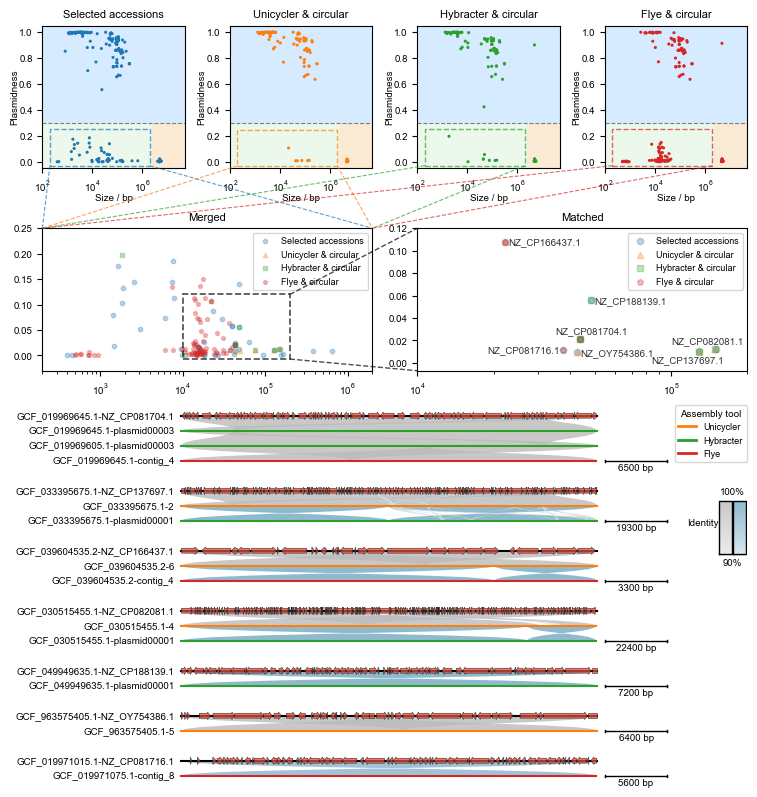

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.transforms import Bbox, TransformedBbox
from matplotlib.lines import Line2D
import pandas as pd
import os

def simple_scatter(ax, df, label='pident_90', color='gray', alpha=1, cat='', marker='o', size=10):
    ax.scatter(df['size'], df[f'average plasmid fraction-{label}'], color=color, 
               edgecolors=color, s=size, alpha=alpha, zorder=3, marker=marker, label=cat)

fig = plt.figure(figsize=(7.5, 7.5))
gap = 0.06
split_size = 1/4
length = split_size - gap
axes = []
for i in range(4):
    axes.append(fig.add_axes([gap+split_size*i, 1-length, length, length]))

merged_bottom = 1-length*2-0.08
ax_merged = fig.add_axes([gap, merged_bottom, length+split_size, length])
ax_matched = fig.add_axes([gap+split_size*2, merged_bottom, length+split_size, length])

scatter_figure(axes[0], contig_info[contig_info['acc_n'].isin(rela_acc)], 'Selected accessions', contig_info, color=plt.cm.tab10(0))
scatter_figure(axes[1], re_assemble[(re_assemble['topology']=='circular') & (re_assemble['tool']=='unicycler')], 'Unicycler & circular', contig_info, color=plt.cm.tab10(1))
scatter_figure(axes[2], re_assemble[(re_assemble['topology']=='circular') & (re_assemble['tool']=='hybracter')], 'Hybracter & circular', contig_info, color=plt.cm.tab10(2))
scatter_figure(axes[3], re_assemble[(re_assemble['topology']=='circular') & (re_assemble['tool']=='flye')], 'Flye & circular', contig_info, color=plt.cm.tab10(3))

simple_scatter(ax_merged, contig_info[contig_info['acc_n'].isin(rela_acc)], label='pident_90',
               color=plt.cm.tab10(0), alpha=0.3, cat='Selected accessions', marker='o')

simple_scatter(ax_merged, re_assemble[(re_assemble['topology']=='circular') & (re_assemble['tool']=='unicycler')], label='pident_90',
               color=plt.cm.tab10(1), alpha=0.3, cat='Unicycler & circular', marker='^')

simple_scatter(ax_merged, re_assemble[(re_assemble['topology']=='circular') & (re_assemble['tool']=='hybracter')], label='pident_90',
               color=plt.cm.tab10(2), alpha=0.3, cat='Hybracter & circular', marker='s')

simple_scatter(ax_merged, re_assemble[(re_assemble['topology']=='circular') & (re_assemble['tool']=='flye')], label='pident_90',
               color=plt.cm.tab10(3), alpha=0.3, cat='Flye & circular', marker='p')

xmin_merge = 2e2
xmax_merge = 2e6
ymin_merge = -0.03
ymax_merge = 0.25

ax_merged.set_xlim(xmin_merge, xmax_merge)
ax_merged.set_ylim(ymin_merge, ymax_merge)
ax_merged.set_xscale('log')
ax_merged.set_title('Merged')
ax_merged.legend(loc='upper right', frameon=True,)

merged_rect_ul_data = (xmin_merge, ymax_merge)
merged_rect_ll_data = (xmax_merge, ymax_merge)
merged_rect_ul_fig = fig.transFigure.inverted().transform(ax_merged.transData.transform(merged_rect_ul_data))
merged_rect_ll_fig = fig.transFigure.inverted().transform(ax_merged.transData.transform(merged_rect_ll_data))

for idx, ax_top in enumerate(axes):
    rect_top = patches.Rectangle((xmin_merge, ymin_merge), width=xmax_merge - xmin_merge, height=ymax_merge - ymin_merge, linewidth=1.0, 
                                 edgecolor=plt.cm.tab10(idx), facecolor="none", linestyle="--", zorder=5, alpha=0.7)
    ax_top.add_patch(rect_top)

    top_rect_ul_data = (xmin_merge, ymin_merge)
    top_rect_ll_data = (xmax_merge, ymin_merge)
    top_rect_ul_fig = fig.transFigure.inverted().transform(ax_top.transData.transform(top_rect_ul_data))
    top_rect_ll_fig = fig.transFigure.inverted().transform(ax_top.transData.transform(top_rect_ll_data))

    top_line_kwargs = dict(color=plt.cm.tab10(idx), lw=0.8, ls="--", transform=fig.transFigure, alpha=0.7)
    line_u = plt.Line2D([top_rect_ul_fig[0], merged_rect_ul_fig[0]],
                        [top_rect_ul_fig[1], merged_rect_ul_fig[1]], **top_line_kwargs)
    line_l = plt.Line2D([top_rect_ll_fig[0], merged_rect_ll_fig[0]],
                        [top_rect_ll_fig[1], merged_rect_ll_fig[1]], **top_line_kwargs)
    fig.add_artist(line_u)
    fig.add_artist(line_l)

simple_scatter(ax_matched, matched_ref, label='pident_90', color=plt.cm.tab10(0), alpha=0.3, cat='Selected accessions', marker='o', size=20)
simple_scatter(ax_matched, overlap_df[(overlap_df['topology']=='circular') & (overlap_df['tool']=='unicycler')], label='pident_90',
               color=plt.cm.tab10(1), alpha=0.3, cat='Unicycler & circular', marker='^', size=20)
simple_scatter(ax_matched, overlap_df[(overlap_df['topology']=='circular') & (overlap_df['tool']=='hybracter')], label='pident_90',
               color=plt.cm.tab10(2), alpha=0.3, cat='Hybracter & circular', marker='s', size=20)
simple_scatter(ax_matched, overlap_df[(overlap_df['topology']=='circular') & (overlap_df['tool']=='flye')], label='pident_90',
               color=plt.cm.tab10(3), alpha=0.3, cat='Flye & circular', marker='p', size=20)

xmin_match = 1e4
xmax_match = 2e5
ymin_match = -0.007
ymax_match = 0.12

ax_matched.set_xlim(xmin_match, xmax_match)
ax_matched.set_ylim(ymin_match, ymax_match)
ax_matched.set_xscale('log')
ax_matched.set_title('Matched')
ax_matched.legend(loc='upper right', frameon=True,)

offset_dirs = [(2,-2),(2,-2),(-34,-8),(2,-2),(-32,4),(-55,-2),(-18,4),(-32,4)]

for i, (_, row) in enumerate(matched_ref.iterrows()):
    x_pt = row["size"]
    y_pt = row["average plasmid fraction-pident_90"]
    txt = row["label_name"]
    dx, dy = offset_dirs[i % len(offset_dirs)]

    ax_matched.annotate(txt, xy=(x_pt, y_pt), xytext=(dx, dy), textcoords="offset points", fontsize=7, color="black", alpha=0.8, zorder=10)

rect = patches.Rectangle((xmin_match, ymin_match), width=xmax_match - xmin_match, height=ymax_match - ymin_match, linewidth=1.2, 
                         edgecolor="black", facecolor="none", linestyle="--", zorder=5, alpha=0.7)
ax_merged.add_patch(rect)

trans_data = ax_merged.transData
trans_ax_match = ax_matched.transAxes

p1_data = (xmax_match, ymax_match)
p2_data = (xmax_match, ymin_match)

p1_fig = fig.transFigure.inverted().transform(trans_data.transform(p1_data))
p2_fig = fig.transFigure.inverted().transform(trans_data.transform(p2_data))

q1_fig = fig.transFigure.inverted().transform(trans_ax_match.transform((0, 1)))
q2_fig = fig.transFigure.inverted().transform(trans_ax_match.transform((0, 0)))

line_kwargs = dict(color="black", lw=1, ls="--", transform=fig.transFigure, alpha=0.7)
l1 = plt.Line2D([p1_fig[0], q1_fig[0]], [p1_fig[1], q1_fig[1]],** line_kwargs)
l2 = plt.Line2D([p2_fig[0], q2_fig[0]], [p2_fig[1], q2_fig[1]], **line_kwargs)

fig.add_artist(l1)
fig.add_artist(l2)

x_site, y_site = gap+0.13, merged_bottom-0.03
right_site = 0.91
align_h = 0.02
for ref_label in all_ref_acc.index:
    y_site = y_site - align_h*(all_ref_acc[ref_label]+1)-0.02
    ax_align = fig.add_axes([x_site, y_site, right_site-x_site, align_h*(all_ref_acc[ref_label]+1)])
    alignment_draw(ax=ax_align, contig_list=all_align_info[ref_label]['all_contigs'], contig_dict=all_align_info[ref_label]['contig_file_info'], 
                   align_result=all_align_info[ref_label]['alignments'], colorbar=False, feature=True, ID_MIN=90)

ax_colorbar = fig.add_axes([right_site+0.05,merged_bottom-0.25,0.04,0.08])
draw_colorbar_legend(ax_colorbar, rel_x=0.1, ID_MIN=90, width=0.08)
ax_colorbar.axis("off")

fig.legend(handles=[Line2D([],[],color=plt.cm.tab10(1),lw=2,label="Unicycler"),
                    Line2D([],[],color=plt.cm.tab10(2),lw=2,label="Hybracter"),
                    Line2D([],[],color=plt.cm.tab10(3),lw=2,label="Flye")], 
           title="Assembly tool", loc="upper right", bbox_to_anchor=(1.005, 0.5),)

os.chdir("/active-data/analysis_results/chr_pla/genus/figures/scatter_plot")
plt.savefig("S_re-assembled_result.svg", bbox_inches="tight", transparent=True)
plt.savefig("S_re-assembled_result.png", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()